<a href="https://colab.research.google.com/github/kevin-ehab/Bus-Operations-AI-Model/blob/main/bus_operations_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Dataset Understanding and EDA
## Subtask 1.1: Load, Preview, and Describe

In [ ]:
df = pd.read_csv('Public_Bus_Operations_Multi_Target.csv')
df.head(5)

,trip_id,weather_condition,bus_type,traffic_level,route_distance_km,stops_count,passenger_count,driver_experience_years,scheduled_start_hour,delay_level,trip_duration_minutes
0,TRIP201396,Windy,Mini Bus,Moderate,13.00,9,23.0,7.91,7,Moderate Delay,53.84
1,TRIP203651,Rainy,Standard,High,4.19,3,26.0,4.03,5,Moderate Delay,40.26
2,TRIP200153,Rainy,Standard,Moderate,4.42,5,26.0,3.90,6,On Time,28.64
3,TRIP209009,Rainy,NaN,Moderate,21.29,19,31.0,4.85,22,Severe Delay,112.70
4,TRIP204405,Clear,Standard,Low,12.37,15,39.0,3.02,20,On Time,47.37


In [ ]:
df.shape

(10000, 11)

## Subtask 1.2: Structure, Summaries, Missing Values, and Duplicates

In [ ]:
df.describe()

,route_distance_km,stops_count,passenger_count,driver_experience_years,scheduled_start_hour,trip_duration_minutes
count,9849.000000,10000.000000,9818.000000,9777.000000,10000.000000,10000.000000
mean,10.622125,11.227500,30.434101,6.151693,13.957900,60.837522
std,5.489059,6.064505,12.695660,3.999918,5.501323,33.956659
min,2.000000,3.000000,3.000000,0.200000,5.000000,12.000000
25%,6.530000,7.000000,21.000000,3.140000,9.000000,36.660000
50%,9.600000,10.000000,31.000000,5.280000,14.000000,52.335000
75%,13.660000,15.000000,39.000000,8.270000,19.000000,76.490000
max,32.000000,37.000000,65.000000,18.000000,23.000000,180.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   trip_id                  10000 non-null  object 
 1   weather_condition        9742 non-null   object 
 2   bus_type                 9798 non-null   object 
 3   traffic_level            10000 non-null  object 
 4   route_distance_km        9849 non-null   float64
 5   stops_count              10000 non-null  int64  
 6   passenger_count          9818 non-null   float64
 7   driver_experience_years  9777 non-null   float64
 8   scheduled_start_hour     10000 non-null  int64  
 9   delay_level              10000 non-null  object 
 10  trip_duration_minutes    10000 non-null  float64
dtypes: float64(4), int64(2), object(5)
memory usage: 859.5+ KB


In [ ]:
na_list = []
col_list = []
for column in df.columns:
  na = df[column].isna().sum().sum()/10000
  if na > 0:
    na_list.append(na)
    col_list.append(column)
pd.DataFrame(index=col_list, data=na_list, columns=['pct of missing values'])

,pct of missing values
weather_condition,0.0258
bus_type,0.0202
route_distance_km,0.0151
passenger_count,0.0182
driver_experience_years,0.0223


In [ ]:
print(f"number of duplicated rows: {df.duplicated().sum()}")

number of duplicated rows: 150


### Quality problems:


*   missing values in `weather_condition`, `bus_type`, `route_distance_km`, `passenger_count`, `driver_experience_years` columns.
*   150 duplicated rows
*   convert the `delay_level` values into numerical values
 ### These must be handled before modeling

## Subtask 1.3: Explore the Classification Target

In [ ]:
df['delay_level'].value_counts()

,count
delay_level,
On Time,3334
Moderate Delay,3333
Severe Delay,3333


In [ ]:
pct_delay_level = df['delay_level'].value_counts()/10000
pct_delay_level = pct_delay_level.map("{:.2%}".format)
pct_delay_level.name = 'percentage'
pct_delay_level

,percentage
delay_level,
On Time,33.34%
Moderate Delay,33.33%
Severe Delay,33.33%


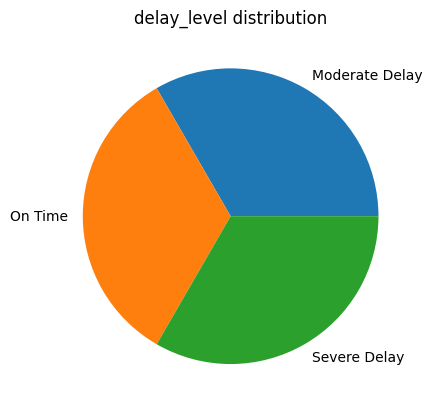

In [ ]:
plt.pie(x=df['delay_level'].value_counts(), labels=df['delay_level'].unique())
plt.title('delay_level distribution')
plt.show()

### Interpretation:
Classes are balanced with each class having a third of the data

## Subtask 1.4: Explore the Regression Target

In [ ]:
print(f"trip_duration_minutes mean: {df['trip_duration_minutes'].mean()}")
print(f"trip_duration_minutes median: {df['trip_duration_minutes'].median()}")
print(f"trip_duration_minutes standard deviation: {df['trip_duration_minutes'].std()}")
print(f"trip_duration_minutes maximum: {df['trip_duration_minutes'].max()}")
print(f"trip_duration_minutes minimum: {df['trip_duration_minutes'].min()}")

trip_duration_minutes mean: 60.8657116751269
trip_duration_minutes median: 52.335
trip_duration_minutes standard deviation: 33.966213291312265
trip_duration_minutes maximum: 180.0
trip_duration_minutes minimum: 12.0


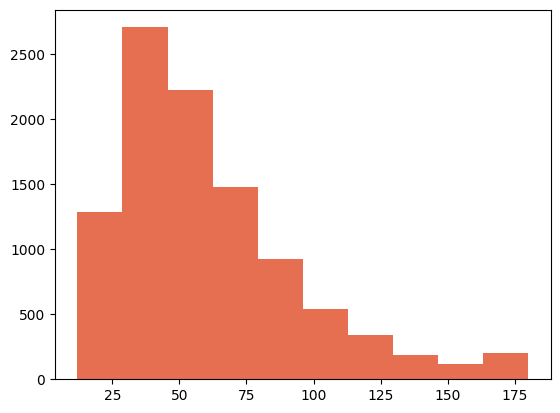

In [ ]:
plt.hist(x=df['trip_duration_minutes'], color='#e76f51')
plt.show()


*   The `trip_duration_minutes` values are left skewed with most values between 25 and 50.
*   There are outliers: the max value is 180 and the min value is 12.


## Subtask 1.5: Investigation

<Axes: >

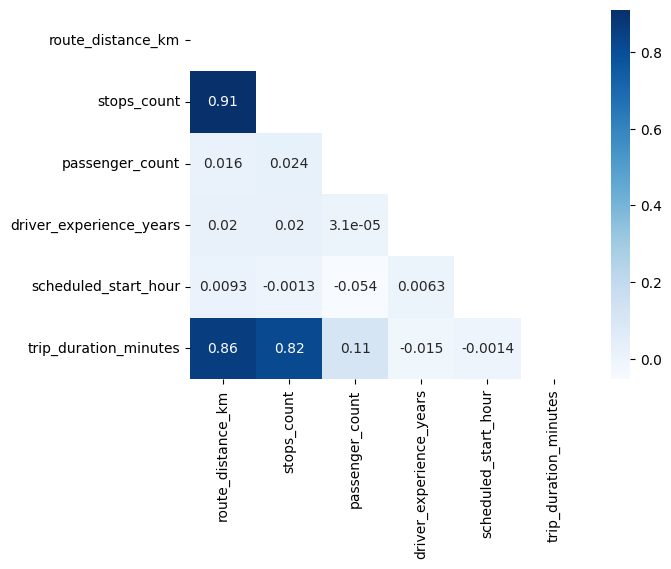

In [ ]:
corr = df.corr(numeric_only=True, method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='Blues', mask=mask)

### Question 1: How does weather correlate duration times?

/tmp/ipykernel_1578/783574224.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


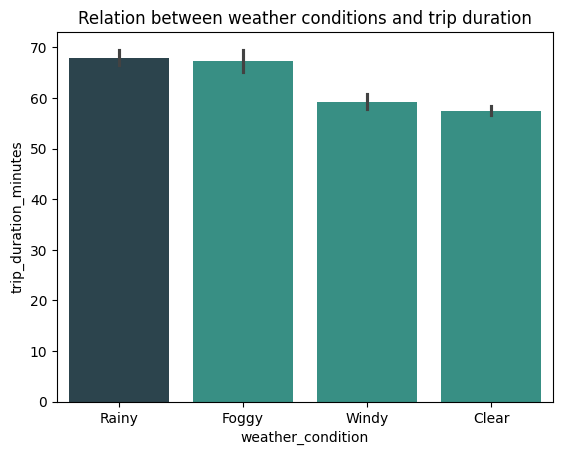

In [ ]:
sns.barplot(
    data=df,
    x='weather_condition',
    y='trip_duration_minutes',
    order=['Rainy', 'Foggy', 'Windy', 'Clear'],
    palette=['#264653', '#2a9d8f', '#2a9d8f', '#2a9d8f'])
plt.title('Relation between weather conditions and trip duration')
plt.show()

Rainy and foggy days tend to have greater trip durations than windy and clear days on average.

### Question 2: How does route distance correlate with trip duration?

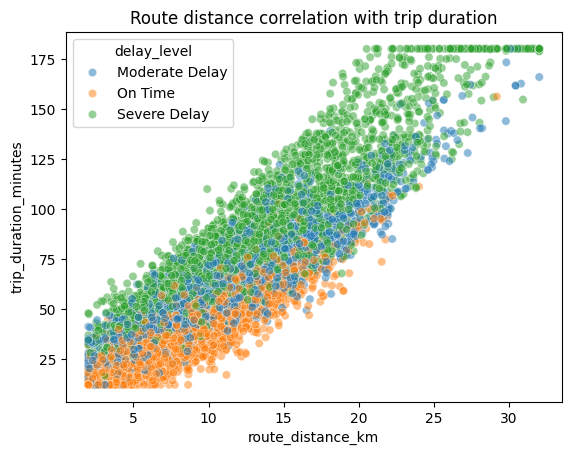

In [ ]:
sns.scatterplot(data=df,
                x='route_distance_km',
                y='trip_duration_minutes',
                hue='delay_level',
                alpha=0.5)
plt.title('Route distance correlation with trip duration')
plt.show()

There is a positive relationship between them: as the distance increases, the trip duration tends to also increase

# Task 2: Prepare Data and Preprocessing

In [ ]:
df.drop_duplicates(inplace=True)
print(f'duplicates after cleaning: {df.duplicated().sum()}')

duplicates after cleaning: 0


Removed the excess duplicated rows to clear unnecessary junk data

In [ ]:
df['delay_level'] = df['delay_level'].map({
    'On Time': 0,
    'Moderate Delay': 1,
    'Severe Delay': 2
})
df.sample(3)

,trip_id,weather_condition,bus_type,traffic_level,route_distance_km,stops_count,passenger_count,driver_experience_years,scheduled_start_hour,delay_level,trip_duration_minutes
524,TRIP209077,Clear,Express,Severe,7.49,8,15.0,9.66,11,0,46.73
5,TRIP208891,Clear,Standard,Moderate,9.79,12,55.0,1.65,18,2,59.05
2079,TRIP206387,Clear,Standard,High,9.33,9,22.0,3.84,6,0,40.44


Mapped the values of `delay_level` to numbers to simplify modeling

In [ ]:
ord_x= ['traffic_level']
nom_x= ['weather_condition', 'bus_type']
num_x= ['route_distance_km'	,'stops_count' ,
        'passenger_count'	,'driver_experience_years',
        'scheduled_start_hour']
x= df[ord_x + nom_x + num_x]
y_classification = df['delay_level']
y_regression = df['trip_duration_minutes']
print(x.shape)
print(y_regression.shape)
print(y_classification.shape)

(9850, 8)
(9850,)
(9850,)


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train_classification, y_test_classification=train_test_split(
    x, y_classification,
    random_state=42,
    stratify=y_classification,
    test_size=0.2
)
y_train_regression = df.loc[y_train_classification.index, 'trip_duration_minutes']
y_test_regression = df.loc[y_test_classification.index, 'trip_duration_minutes']
print(x_train.shape)
print(x_test.shape)

(7880, 8)
(1970, 8)


The spliting strategy used is 80/20 split because it gives a good balance between the two competing goals

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
ordinal_transformer= Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[['Low', 'Moderate', 'High', 'Severe']]))
])
nominal_transformer= Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])
numeric_transformer= Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer(transformers=[
    ('ord', ordinal_transformer, ord_x),
    ('nom', nominal_transformer, nom_x),
    ('num', numeric_transformer, num_x)
])
preprocessor

ColumnTransformer(transformers=[('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Moderate',
                                                                              'High',
                                                                              'Severe']]))]),
                                 ['traffic_level']),
                                ('nom',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['weather_condition', 'bus_type']),
                                ('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['route_distance_km', 'stops_count',
                                  'passenger_count', 'driver_experience_years',
                                  'scheduled_start_hour'])])

# Task 3: Classification Model Comparison

## Subtask 3.1: Define the Classification Models to Compare

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
model_search_space_classification = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=2000, random_state=42),
        'parameters': {
            'model__C': [0.1, 1, 10],
            'model__class_weight': [None, 'balanced'],
        },
    },
    'SVC': {
        'model': SVC(random_state=42),
        'parameters': [
            {
                'model__kernel': ['linear'],
                'model__C': [0.1, 1, 10],
                'model__class_weight': [None, 'balanced'],
            },
            {
                'model__kernel': ['rbf'],
                'model__C': [1, 10],
                'model__gamma': ['scale', 0.1],
                'model__class_weight': [None, 'balanced'],
            },
        ],
    }
}

This is the search space for the grid seach cv to test all the models with their respective parameters to find the best model

## Subtask 3.2: Train and Compare the Classification Models

In [ ]:
from sklearn.model_selection import GridSearchCV
results_classification = {}

for name, config in model_search_space_classification.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', config['model'])
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config['parameters'],
        cv=5,
        scoring='f1_macro',
        n_jobs=-1
    )
    grid_search.fit(x_train, y_train_classification)
    results_classification[name] = grid_search
    best_index = grid_search.best_index_
    mean_cv_f1 = grid_search.cv_results_['mean_test_score'][best_index]
    std_cv_f1 = grid_search.cv_results_['std_test_score'][best_index]

    print(f"\n{name}")
    print("Best parameters:", grid_search.best_params_)
    print(f"Mean CV F1-macro: {mean_cv_f1:.4f}")
    print(f"CV F1-macro standard deviation: {std_cv_f1:.4f}")


Logistic Regression
Best parameters: {'model__C': 10, 'model__class_weight': 'balanced'}
Mean CV F1-macro: 0.6718
CV F1-macro standard deviation: 0.0080

SVC
Best parameters: {'model__C': 1, 'model__class_weight': 'balanced', 'model__gamma': 0.1, 'model__kernel': 'rbf'}
Mean CV F1-macro: 0.7007
CV F1-macro standard deviation: 0.0086


In [ ]:
best_classification_model = results_classification['SVC'].best_estimator_

So the best model is the SVC with these parameters because it gave the greatest F1-macro score.

## Subtask 3.3: Final Evaluation on Test Data

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
y_pred_classification = best_classification_model.predict(x_test)
print(f'accuracy score: {accuracy_score(y_test_classification, y_pred_classification):.4}')
print(f'macro precision score: {precision_score(y_test_classification, y_pred_classification, average='macro'):.4}')
print(f'macro recall score: {recall_score(y_test_classification, y_pred_classification, average='macro'):.4}')
print(f'macro F1 score: {f1_score(y_test_classification, y_pred_classification, average='macro'):.4}')

accuracy score: 0.7183
macro precision score: 0.7159
macro recall score: 0.7182
macro F1 score: 0.7168


In [ ]:
print(classification_report(y_test_classification, y_pred_classification))

              precision    recall  f1-score   support

           0       0.76      0.80      0.78       656
           1       0.59      0.56      0.58       656
           2       0.80      0.79      0.79       658

    accuracy                           0.72      1970
   macro avg       0.72      0.72      0.72      1970
weighted avg       0.72      0.72      0.72      1970



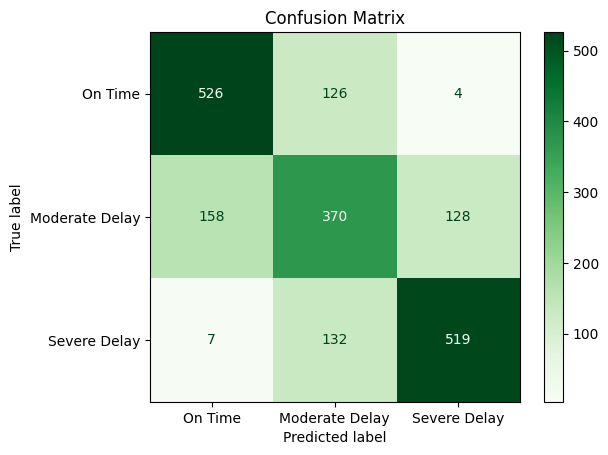

In [ ]:
cm = confusion_matrix(y_test_classification, y_pred_classification)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=['On Time', 'Moderate Delay', 'Severe Delay']
)
disp.plot(cmap='Greens')
plt.title('Confusion Matrix')
plt.show()

### Interpretation:
The selected model achieved 71.83% accuracy with a 71.68% macro F1-score, showing reasonable overall performance.
It performed best on Class 2 (Severe Delay) with an F1-score of 0.79, followed by Class 0 (On Time) at 0.78.
Performance was weaker for Class 1 (Moderate Delay), with an F1-score of 0.58.<br>
Most errors involved confusing On Time trips with the two delay classes.

# Task 4: Regression Model Comparison
## Subtask 4.1: Define the Regression Models to Compare

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
model_search_space_regression = {
    'Linear Regression': {
        'model': LinearRegression(),
        'parameters': {
            'model__fit_intercept': [True, False],
        },
    },
    'KNN Regressor': {
        'model': KNeighborsRegressor(),
        'parameters': {
            'model__n_neighbors': [5, 9, 15],
            'model__weights': ['uniform', 'distance'],
            'model__p': [1, 2],
        },
    }
}

## Subtask 4.2: Train and Compare the Regression Models

In [ ]:
results_regression = {}

for name, config in model_search_space_regression.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', config['model'])
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config['parameters'],
        cv=5,
        scoring='r2',
        n_jobs=-1
    )
    grid_search.fit(x_train, y_train_regression)
    results_regression[name] = grid_search
    best_index = grid_search.best_index_
    mean_cv_r2 = grid_search.cv_results_['mean_test_score'][best_index]
    std_cv_r2 = grid_search.cv_results_['std_test_score'][best_index]
    print(f"\n{name}")
    print("Best parameters:", grid_search.best_params_)
    print(f"Mean CV R2: {mean_cv_r2:.4f}")
    print(f"CV R2 standard deviation: {std_cv_r2:.4f}")


Linear Regression
Best parameters: {'model__fit_intercept': True}
Mean CV R2: 0.9237
CV R2 standard deviation: 0.0049

KNN Regressor
Best parameters: {'model__n_neighbors': 9, 'model__p': 2, 'model__weights': 'distance'}
Mean CV R2: 0.9266
CV R2 standard deviation: 0.0028


In [ ]:
best_regression_model = results_regression['KNN Regressor'].best_estimator_

The best model is KNN with these parameters because it produced the greatest R2 score.

## Subtask 4.3: Final Evaluation on Test Data

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)
y_pred_regression = best_regression_model.predict(x_test)
print(f'mean absolute error: {mean_absolute_error(y_test_regression, y_pred_regression):.4}')
print(f'root mean squared error: {root_mean_squared_error(y_test_regression, y_pred_regression):.4}')
print(f'r2 score: {r2_score(y_test_regression, y_pred_regression):.4}')

mean absolute error: 6.671
root mean squared error: 8.552
r2 score: 0.936


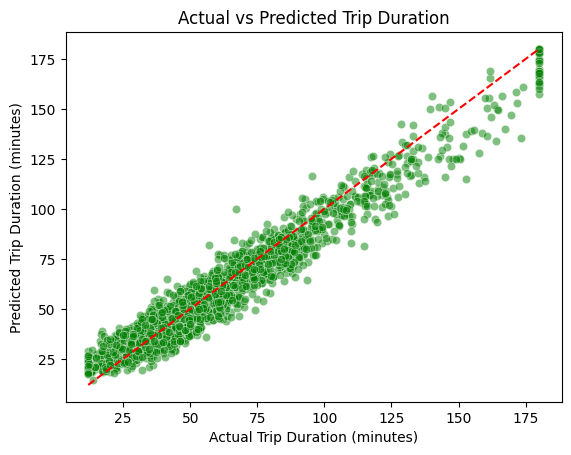

In [ ]:
sns.scatterplot(x=y_test_regression, y=y_pred_regression, alpha=0.5, color='green')

# Perfect prediction line
plt.plot(
    [y_test_regression.min(), y_test_regression.max()],
    [y_test_regression.min(), y_test_regression.max()],
    linestyle='--',
    color='red'
)
plt.xlabel('Actual Trip Duration (minutes)')
plt.ylabel('Predicted Trip Duration (minutes)')
plt.title('Actual vs Predicted Trip Duration')
plt.show()

The model has a typical error of 6.67 minutes (MAE), which is small relative to typical trip durations.
It is suitable for schedule planning and arrival-time estimation, but less reliable for passenger communication due to potential timing discrepancies.
The RMSE of 8.55 minutes indicates some larger errors, and the plot shows predictions generally close to actual values but with greater deviations for some longer trips.


# Task 5: Model Saving and Predictions
## Subtask 5.1: Save, Reload, and Verify Both Pipelines

In [ ]:
import joblib
joblib.dump(best_classification_model,'EYOUTH-30811012400538_best_bus_delay_classifier.joblib')
joblib.dump(best_regression_model,'EYOUTH-30811012400538_best_bus_duration_regressor.joblib')
print('Saved successfully')

Saved successfully


In [ ]:
loaded_classification_model = joblib.load('EYOUTH-30811012400538_best_bus_delay_classifier.joblib')
loaded_regression_model = joblib.load('EYOUTH-30811012400538_best_bus_duration_regressor.joblib')
print('Loaded successfully')

Loaded successfully


## Subtask 5.2: Predict the 10 New Trips

In [ ]:
new_trips = pd.read_csv('New_Bus_Trips.csv')
predicted_delay_level = loaded_classification_model.predict(
    new_trips.drop('trip_id',axis=1)
)
predicted_trip_duration_minutes = loaded_regression_model.predict(
    new_trips.drop('trip_id',axis=1)
)
prediction_table = pd.DataFrame({
    'trip_id': new_trips['trip_id'],
    'predicted_delay_level': predicted_delay_level,
    'predicted_trip_duration_minutes':predicted_trip_duration_minutes
})
prediction_table['predicted_delay_level'] = prediction_table['predicted_delay_level'].map({
    0: 'On Time',
    1: 'Moderate Delay',
    2: 'Severe Delay'
})
prediction_table

,trip_id,predicted_delay_level,predicted_trip_duration_minutes
0,NEW001,On Time,22.076209
1,NEW002,Severe Delay,96.598627
2,NEW003,Severe Delay,170.731375
3,NEW004,On Time,45.107040
4,NEW005,Severe Delay,65.414810
5,NEW006,Severe Delay,159.343970
6,NEW007,On Time,21.936624
7,NEW008,Moderate Delay,78.571695
8,NEW009,Severe Delay,61.447175
9,NEW010,Severe Delay,161.285763
